In [ ]:
from google.colab import files
uploaded = files.upload()  # click to upload your JPEG


Saving decoded-20260419105547.jpeg to decoded-20260419105547.jpeg


In [ ]:
import requests, base64

# Get the uploaded filename automatically
filename = list(uploaded.keys())[0]

# Encode image
with open(filename, "rb") as f:
    b64 = base64.b64encode(f.read()).decode()

# Call API
response = requests.post(
    "https://apple-pruner-api-34w2yszeuq-ez.a.run.app",
    headers={"Content-Type": "application/json"},
    json={"instances": [{"content": b64}]}
)

print("Status:", response.status_code)
print("Response:", response.json())


Status: 200
Response: {'results': "[{'confidences': [0.120985776, 0.0837799385, 0.0779819414, 0.0684910342, 0.0661456883, 0.0643509626, 0.0639177412, 0.0628758147, 0.0625412911, 0.0620693043, 0.0614691973, 0.0594018809, 0.0571848601, 0.0571560189, 0.0559770502, 0.0523370169, 0.0522437468, 0.0520204641, 0.0515430085, 0.0513201952, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'displayNames': ['water_sprout', 'water_sprout', 'fruit_branch', 'water_sprout', 'water_sprout', 'secondary', 'secondary', 'secondary', 'water_sprout', 'secondary', 'water_sprout', 'secondary', 'transfer_cut', 'secondary', 'fruit_branch', 'transfer_cut', 'secondary', 'water_sprout', 'water_sprout', 'water_sprout', 'competitive_branch', 'competitive_branch', 'competitive_branch', 'competitive_branch', 'competitive_branch', 'competitive_branch', 'competitive_branch', 'competitive_branch', 'competitive_branch', 'competitive_branch', 'competitive_branch', 'competit

In [ ]:
import json
print(json.dumps(response.json(), indent=2))

{
  "results": "[{'confidences': [0.120985776, 0.0837799385, 0.0779819414, 0.0684910342, 0.0661456883, 0.0643509626, 0.0639177412, 0.0628758147, 0.0625412911, 0.0620693043, 0.0614691973, 0.0594018809, 0.0571848601, 0.0571560189, 0.0559770502, 0.0523370169, 0.0522437468, 0.0520204641, 0.0515430085, 0.0513201952, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'displayNames': ['water_sprout', 'water_sprout', 'fruit_branch', 'water_sprout', 'water_sprout', 'secondary', 'secondary', 'secondary', 'water_sprout', 'secondary', 'water_sprout', 'secondary', 'transfer_cut', 'secondary', 'fruit_branch', 'transfer_cut', 'secondary', 'water_sprout', 'water_sprout', 'water_sprout', 'competitive_branch', 'competitive_branch', 'competitive_branch', 'competitive_branch', 'competitive_branch', 'competitive_branch', 'competitive_branch', 'competitive_branch', 'competitive_branch', 'competitive_branch', 'competitive_branch', 'competitive_branch', 'compe

In [ ]:
# Define all known labels and their colors
LABELS = {
    "leader":               "yellow",
    "fruit_bud":            "pink",
    "water_sprout":         "red",
    "fruit_branch":         "green",
    "secondary":            "blue",
    "transfer_cut":         "orange",
    "competitive_branch":   "purple"
}

print("Defined labels:")
for label, color in LABELS.items():
    print(f"  {label:25} → {color}")


Defined labels:
  leader                    → yellow
  fruit_bud                 → pink
  water_sprout              → red
  fruit_branch              → green
  secondary                 → blue
  transfer_cut              → orange
  competitive_branch        → purple


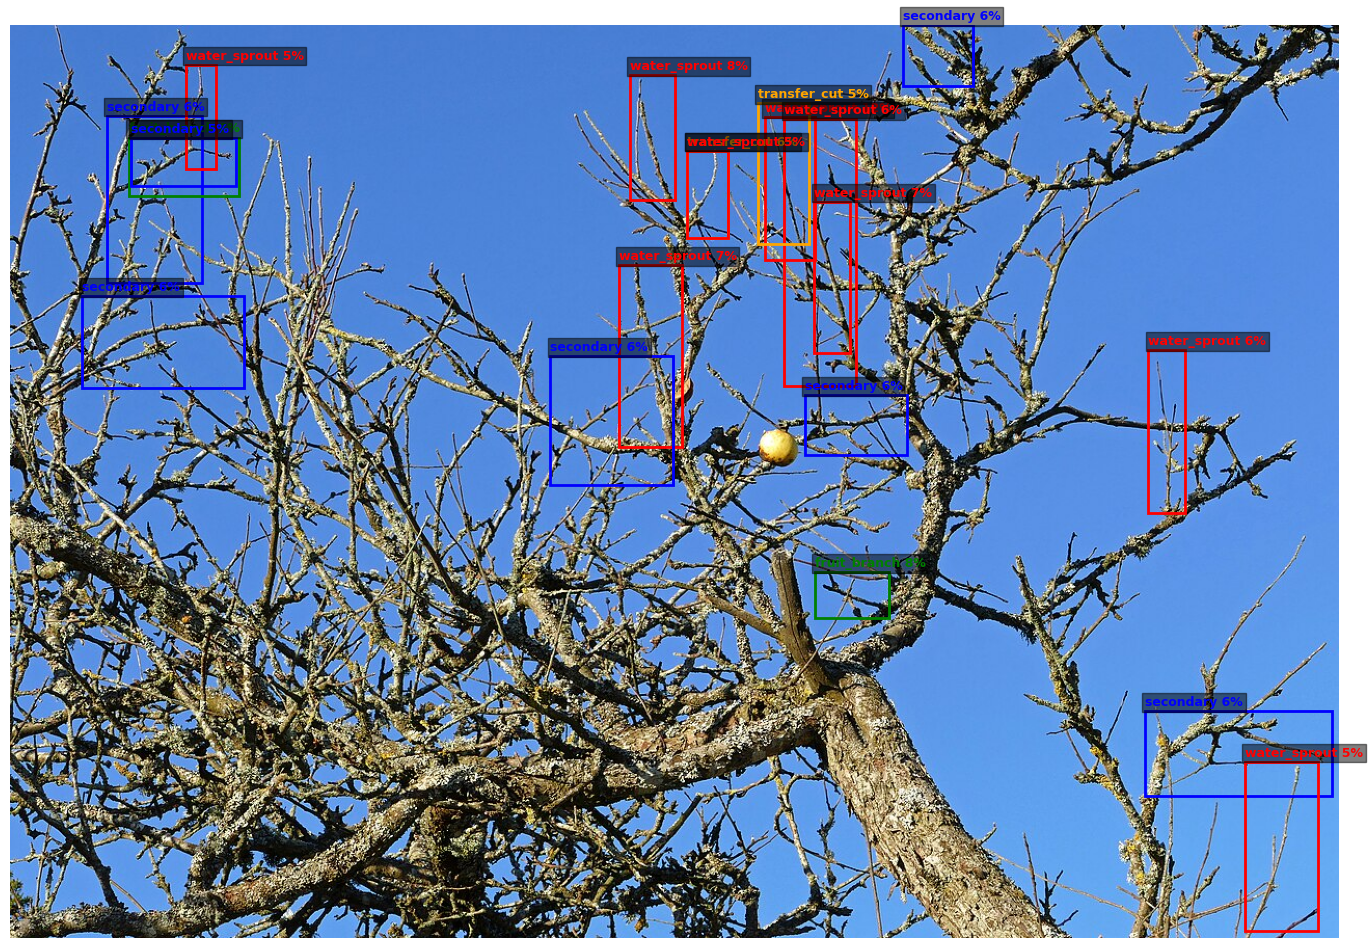

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import ast, io

# Parse response
raw = ast.literal_eval(response.json()["results"])[0]

# Load image
img = Image.open(filename)
img_w, img_h = img.size

fig, ax = plt.subplots(1, figsize=(14, 10))
ax.imshow(img)

# Color per class
colors = {
    "water_sprout": "red",
    "fruit_branch": "green",
    "secondary": "blue",
    "transfer_cut": "orange",
    "competitive_branch": "purple"

}

# Draw boxes
for i in range(len(raw["confidences"])):
    conf = raw["confidences"][i]
    if conf == 0.0:
        continue

    label = raw["displayNames"][i]
    bbox = raw["bboxes"][i]

    # Convert normalized coords to pixels
    x_min = bbox[0] * img_w
    x_max = bbox[1] * img_w
    y_min = bbox[2] * img_h
    y_max = bbox[3] * img_h

    color = colors.get(label, "white")

    rect = patches.Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        linewidth=2,
        edgecolor=color,
        facecolor="none"
    )
    ax.add_patch(rect)
    ax.text(x_min, y_min - 5, f"{label} {conf:.0%}",
            color=color, fontsize=9, fontweight="bold",
            bbox=dict(facecolor="black", alpha=0.5, pad=2))

plt.axis("off")
plt.tight_layout()
plt.show()